In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk

import tensorflow as tf

import yfinance as yf

In [ ]:
tickers = yf.Tickers('GOOG, META, NVDA, AMZN, MSFT')

In [ ]:
google_data = tickers.tickers['GOOG']
meta_data = tickers.tickers['META']
nvidia_data = tickers.tickers['NVDA']
amazon_data = tickers.tickers['AMZN']
microsoft_data = tickers.tickers['MSFT']

In [ ]:
google_news = google_data.news

In [15]:
from pygooglenews import GoogleNews

In [59]:
gn = GoogleNews(lang = "en", country = "US")
google_news = gn.search('Apple', from_='2025-01-01', to_='2026-01-27')

In [61]:
google_news

{'feed': {'generator_detail': {'name': 'NFE/5.0'},
  'generator': 'NFE/5.0',
  'title': '"Apple after:2025-01-01 before:2026-01-27" - Google News',
  'title_detail': {'type': 'text/plain',
   'language': None,
   'base': '',
   'value': '"Apple after:2025-01-01 before:2026-01-27" - Google News'},
  'links': [{'rel': 'alternate',
    'type': 'text/html',
    'href': 'https://news.google.com/search?q=Apple+after:2025-01-01+before:2026-01-27&ceid=US:en&hl=en-US&gl=US'}],
  'link': 'https://news.google.com/search?q=Apple+after:2025-01-01+before:2026-01-27&ceid=US:en&hl=en-US&gl=US',
  'language': 'en-US',
  'publisher': 'news-webmaster@google.com',
  'publisher_detail': {'email': 'news-webmaster@google.com'},
  'rights': 'Copyright © 2026 Google. All rights reserved. This XML feed is made available solely for the purpose of rendering Google News results within a personal feed reader for personal, non-commercial use. Any other use of the feed is expressly prohibited. By accessing this feed 

In [63]:
for entry in google_news['entries']:
    print(entry['title'])

Apple debuts iPhone 16e: A powerful new member of the iPhone 16 family - Apple
Introducing iPhone Air, a powerful new iPhone with a breakthrough design - Apple
Apple Intelligence gets even more powerful with new capabilities across Apple devices - Apple
iPhone 17 Pro and iPhone 17 Pro Max - Apple
Apple unveils powerful accessibility features coming later this year - Apple
Apple increases U.S. commitment to $600 billion, announces ambitious program - Apple
Apple debuts iPhone 17 - Apple
Apple Vision Pro upgraded with the M5 chip and Dual Knit Band - Apple
Apple unveils iPhone 17 Pro and iPhone 17 Pro Max, the most powerful and advanced Pro models ever - Apple
Apple will spend more than $500 billion in the U.S. over the next four years - Apple
Apple elevates the iPhone experience with iOS 26 - Apple
New versions of Apple’s software platforms are available today - Apple
A major evolution of Apple Security Bounty, with the industry's top awards for the most advanced research - Apple Securi

In [37]:
len(google_news['entries'])

100

In [45]:
help(gn.search)

Help on method search in module pygooglenews:

search(query: str, helper=True, when=None, from_=None, to_=None, proxies=None, scraping_bee=None) method of pygooglenews.GoogleNews instance
    Return a list of all articles given a full-text search parameter,
    a country and a language

    :param bool helper: When True helps with URL quoting
    :param str when: Sets a time range for the artiles that can be found



In [47]:
import datetime

In [53]:
start_date = datetime.date(2025, 1, 1)
end_date = datetime.date(2025, 1, 10)
delta = datetime.timedelta(days=1)

google_news_all = []

current_date = start_date
ticker = 'google'

while current_date <= end_date:
    next_date = current_date + delta
    search = gn.search(f'{ticker} after:{current_date} before:{next_date}')
    google_news_all.extend(search['entries'])
    print(f" - {len(search['entries'])} entries for {current_date} collected")
    current_date = next_date

 - 21 entries for 2025-01-01 collected
 - 29 entries for 2025-01-02 collected
 - 22 entries for 2025-01-03 collected
 - 12 entries for 2025-01-04 collected
 - 57 entries for 2025-01-05 collected
 - 87 entries for 2025-01-06 collected
 - 79 entries for 2025-01-07 collected
 - 97 entries for 2025-01-08 collected
 - 88 entries for 2025-01-09 collected
 - 33 entries for 2025-01-10 collected


In [65]:
print(google_news_all[0])

{'title': 'Google\'s new "thinking" model isn\'t quite as good as o1 - understandingai.org', 'title_detail': {'type': 'text/plain', 'language': None, 'base': '', 'value': 'Google\'s new "thinking" model isn\'t quite as good as o1 - understandingai.org'}, 'links': [{'rel': 'alternate', 'type': 'text/html', 'href': 'https://news.google.com/rss/articles/CBMie0FVX3lxTE5zeHJkU2xLMC03ZlNHVnlvRzAtUmJabzNpbnNCaFhVQWU0dkRKa0JuMUVtSmZHTGpGTXBDR2RENVU1RUU3QThuOGowUi1SaUdLMlhyVUN6TGdmWUJwOWxYWFRFZWJRNjY4U2d6VWJHYWMtRFNTYjdWNFZTOA?oc=5'}], 'link': 'https://news.google.com/rss/articles/CBMie0FVX3lxTE5zeHJkU2xLMC03ZlNHVnlvRzAtUmJabzNpbnNCaFhVQWU0dkRKa0JuMUVtSmZHTGpGTXBDR2RENVU1RUU3QThuOGowUi1SaUdLMlhyVUN6TGdmWUJwOWxYWFRFZWJRNjY4U2d6VWJHYWMtRFNTYjdWNFZTOA?oc=5', 'id': 'CBMie0FVX3lxTE5zeHJkU2xLMC03ZlNHVnlvRzAtUmJabzNpbnNCaFhVQWU0dkRKa0JuMUVtSmZHTGpGTXBDR2RENVU1RUU3QThuOGowUi1SaUdLMlhyVUN6TGdmWUJwOWxYWFRFZWJRNjY4U2d6VWJHYWMtRFNTYjdWNFZTOA', 'guidislink': False, 'published': 'Thu, 02 Jan 2025 08:00:00 GM

In [4]:
google_history_1yr = google_data.history(period = "1y")
meta_history_1yr = meta_data.history(period = "1y")
nvidia_history_1yr = nvidia_data.history(period = "1y")
amazon_history_1yr = amazon_data.history(period = "1y")
microsoft_history_1yr = microsoft_data.history(period = "1y")

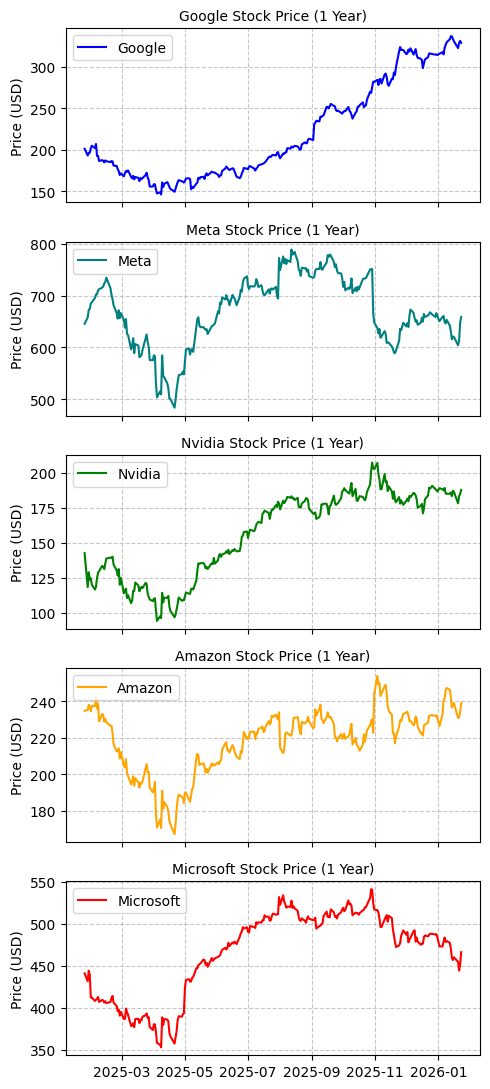

In [5]:
histories = [google_history_1yr, meta_history_1yr, nvidia_history_1yr, amazon_history_1yr, microsoft_history_1yr]
titles = ['Google', 'Meta', 'Nvidia', 'Amazon', 'Microsoft']
colors = ['blue', 'teal', 'green', 'orange', 'red']

fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(5, 11), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(histories[i].index, histories[i]['Close'], color=colors[i], label=titles[i])

    ax.set_title(f"{titles[i]} Stock Price (1 Year)", fontsize=10)
    ax.set_ylabel("Price (USD)")
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [6]:
from sklearn.preprocessing import MinMaxScaler

df = pd.concat([
    google_history_1yr['Close'],
    meta_history_1yr['Close'],
    nvidia_history_1yr['Close'],
    amazon_history_1yr['Close'],
    microsoft_history_1yr['Close']
], axis=1)
df.columns = ['GOOG','META','NVDA','AMZN','MSFT']
df.dropna(inplace=True)

train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df)

test_scaled = scaler.transform(test_df)

def create_dataset(dataset, window_size=60):
    X, y = [], []
    for i in range(len(dataset) - window_size):
        X.append(dataset[i:i+window_size])
        y.append(dataset[i+window_size])
    return np.array(X), np.array(y)

X_train, y_train = create_dataset(train_scaled, 60)

full_test_data = np.vstack((train_scaled[-60:], test_scaled))
X_test, y_test = create_dataset(full_test_data, 60)

In [7]:
from tensorflow.keras.layers import Dense, LSTM, Input, BatchNormalization
from tensorflow.keras.models import Model

In [8]:
window_size = 60

input_layer = Input(shape = (window_size, 5))
batch_norm_layer = BatchNormalization()(input_layer)
LSTM_layer = LSTM(16)(batch_norm_layer)
output_layer = Dense(1, activation = "relu")(LSTM_layer)

model = Model(inputs = input_layer, outputs = output_layer)
model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics=['mae'])

In [9]:
model.fit(X_train, y_train, epochs = 10, batch_size = 64)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2314 - mae: 0.3834  
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1975 - mae: 0.3516 
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1795 - mae: 0.3343 
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1523 - mae: 0.3075 
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1198 - mae: 0.2744 
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0977 - mae: 0.2437 
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0879 - mae: 0.2343 
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0771 - mae: 0.2174 
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0666 - mae: 0.1988 
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0585 - mae: 0.1867 


In [10]:
loss, mae = model.evaluate(X_test, y_test)

print(f"loss: {loss}")
print(f"mae: {mae}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0843 - mae: 0.2082  
loss: 0.08428642898797989
mae: 0.20824413001537323
